# Data Check & EDA

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Unzip Dataset

In [3]:
!unzip -o -q "/content/drive/MyDrive/Dataset/garbage_classification/garbage_data.zip" -d "./garbage_classification"
!ls ./garbage_classification

'garbage classification'	       one-indexed-files-notrash_val.txt
'Garbage classification'	       one-indexed-files.txt
 one-indexed-files-notrash_test.txt    zero-indexed-files.txt
 one-indexed-files-notrash_train.txt


## Set Dataset Path

In [4]:
import os

dataset_path = "./garbage_classification/Garbage classification/Garbage classification"

classes = [cls for cls in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, cls))]
print("Final Classes:", classes)

Final Classes: ['metal', 'cardboard', 'paper', 'plastic', 'glass', 'trash']


## Count Images per Class

In [5]:
class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes}
print("Image counts per class:", class_counts)

Image counts per class: {'metal': 410, 'cardboard': 403, 'paper': 594, 'plastic': 482, 'glass': 501, 'trash': 137}


## Visualize Class Distribution

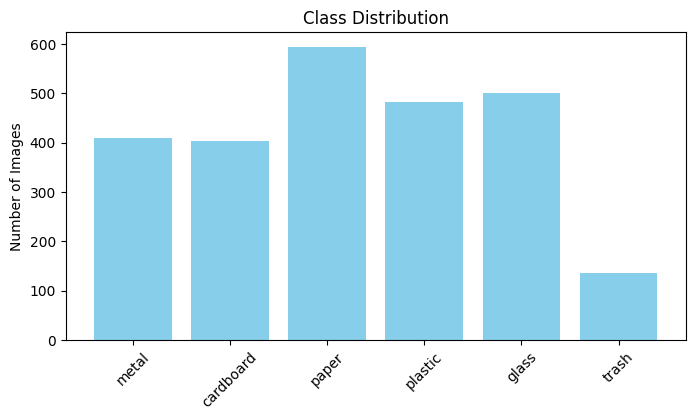

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

## Show Sample Images

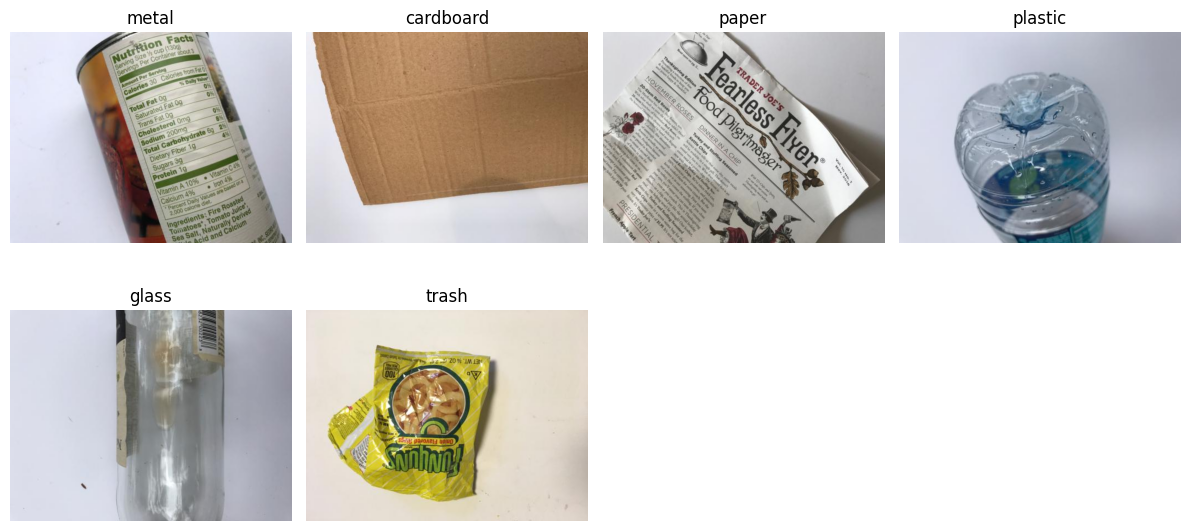

In [7]:
import cv2

plt.figure(figsize=(12,6))
for idx, cls in enumerate(classes):
    img_path = os.path.join(dataset_path, cls, os.listdir(os.path.join(dataset_path, cls))[0])
    img = cv2.imread(img_path)[:,:,::-1]  # BGR → RGB
    plt.subplot(2, len(classes)//2 + 1, idx+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

##  Train/Validation Split + Data Loader

In [8]:
import tensorflow as tf

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Import Libraries

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Define CNN Model

In [10]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),   # normalize
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.2875 - loss: 1.6777 - val_accuracy: 0.4396 - val_loss: 1.3843
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4711 - loss: 1.3051 - val_accuracy: 0.4139 - val_loss: 1.4636
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5268 - loss: 1.2297 - val_accuracy: 0.5822 - val_loss: 1.1274
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6310 - loss: 1.0186 - val_accuracy: 0.5881 - val_loss: 1.0965
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6901 - loss: 0.8608 - val_accuracy: 0.5545 - val_loss: 1.1709
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7301 - loss: 0.7656 - val_accuracy: 0.5861 - val_loss: 1.1777
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7802 - loss: 0.6127 - val_accuracy: 0.6079 - val_loss: 1.1798
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8281 - loss: 0.4806 - val_accuracy: 0.5465 - val_los

## Plot Training Results

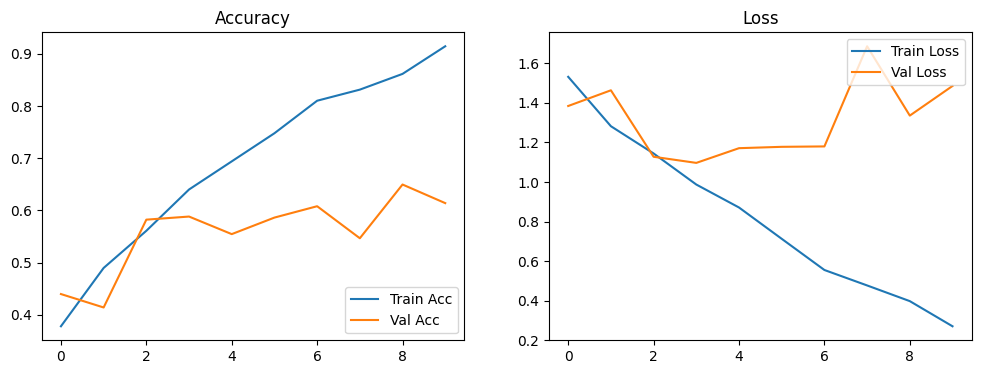

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()

## Transfer Learning with MobileNetV2

## Data Augmentation (stronger)


In [46]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

## Build Model (MobileNetV2 backbone)

In [47]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(128,128,3)
)
base_model.trainable = False  # feature extractor stage

num_classes = len(class_names)

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_13 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Build Model (MobileNetV2 backbone)

In [48]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(128,128,3)
)
base_model.trainable = False  # feature extractor stage

num_classes = len(class_names)

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_13 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compile Model

In [49]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Train (Feature Extraction with class_weight)

In [50]:
class_weight = {
    0: 1.0,  # metal
    1: 1.0,  # cardboard
    2: 1.0,  # paper
    3: 1.0,  # plastic
    4: 1.0,  # glass
    5: 1.5   # trash (rare class)
}

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.2952 - loss: 2.0539 - val_accuracy: 0.6218 - val_loss: 0.9989 - learning_rate: 0.0010
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6127 - loss: 1.1203 - val_accuracy: 0.6812 - val_loss: 0.8835 - learning_rate: 0.0010
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6285 - loss: 1.0315 - val_accuracy: 0.7248 - val_loss: 0.8026 - learning_rate: 0.0010
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6640 - loss: 0.9538 - val_accuracy: 0.7228 - val_loss: 0.7756 - learning_rate: 0.0010
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6983 - loss: 0.8691 - val_accuracy: 0.7545 - val_loss: 0.7300 - learning_rate: 0.0010
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7295 - loss: 0.7774 - val_accuracy: 0.7604 - val_loss: 0.7180 - learning_rate: 0.0010
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7208 - loss: 0.7897 - val_acc

## Fine-tuning MobileNetV2 (longer training)

In [51]:
# Unfreeze last 20 layers (already done previously)
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

# Train longer
fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,                  # was 10 → now 30
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.5802 - loss: 1.3227 - val_accuracy: 0.7743 - val_loss: 0.6638 - learning_rate: 1.0000e-05
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6395 - loss: 1.0813 - val_accuracy: 0.7762 - val_loss: 0.6558 - learning_rate: 1.0000e-05
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6625 - loss: 0.9533 - val_accuracy: 0.7782 - val_loss: 0.6552 - learning_rate: 1.0000e-05
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6806 - loss: 0.9415 - val_accuracy: 0.7822 - val_loss: 0.6524 - learning_rate: 1.0000e-05
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7124 - loss: 0.8314 - val_accuracy: 0.7802 - val_loss: 0.6493 - learning_rate: 1.0000e-05
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7132 - loss: 0.8134 - val_accuracy: 0.7941 - val_loss: 0.6424 - learning_rate: 1.0000e-05
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7120

## Confusion Matrix

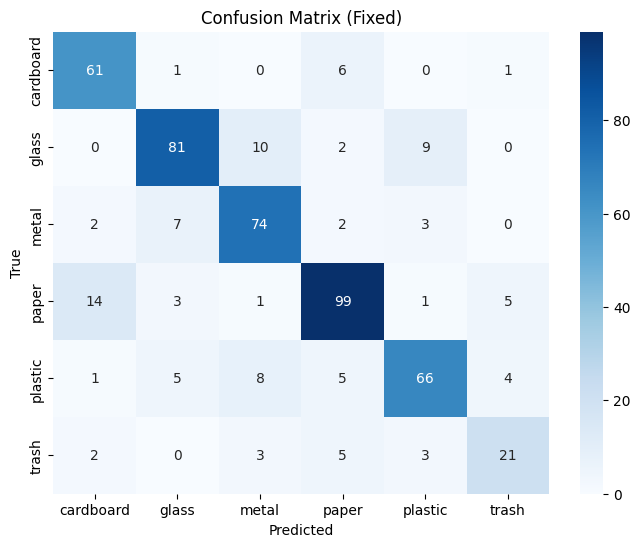

              precision    recall  f1-score   support

   cardboard     0.7625    0.8841    0.8188        69
       glass     0.8351    0.7941    0.8141       102
       metal     0.7708    0.8409    0.8043        88
       paper     0.8319    0.8049    0.8182       123
     plastic     0.8049    0.7416    0.7719        89
       trash     0.6774    0.6176    0.6462        34

    accuracy                         0.7960       505
   macro avg     0.7804    0.7805    0.7789       505
weighted avg     0.7973    0.7960    0.7953       505



In [60]:
# Ensure deterministic ordering
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=val_ds.class_names,
            yticklabels=val_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Fixed)")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=val_ds.class_names, digits=4))